# CNN 经典架构

> **斯坦福 CS231n Lecture 6** | CNN Architectures

## 本章导读

从 AlexNet 到 ResNet，本节梳理经典 CNN 架构的演进脉络，理解每个架构的创新点和设计思想。我们将从零实现关键组件并可视化架构差异。

**学习目标：**
- 理解 AlexNet、VGG、GoogLeNet、ResNet 的架构创新
- 掌握 Batch Normalization 原理
- 理解残差连接为何能训练极深网络
- 从零实现 BatchNorm 和 Residual Block

**参考来源：** [CS231n CNN Architectures](https://cs231n.github.io/convolutional-networks/)

## 1. 架构演进概览

| 年份 | 架构 | 层数 | Top-5 错误率 | 核心创新 |
|------|------|------|-------------|----------|
| 2012 | AlexNet | 8 | 15.3% | ReLU, Dropout, GPU |
| 2014 | VGG | 16-19 | 7.3% | 小卷积核堆叠 |
| 2014 | GoogLeNet | 22 | 6.7% | Inception 模块 |
| 2015 | ResNet | 152 | 3.6% | 残差连接 |

[[He et al., 2015]](https://arxiv.org/abs/1512.03385) ResNet 论文

### 关键趋势
1. **更深**：8层 → 152层
2. **更小的卷积核**：11×11 → 3×3
3. **更少的参数**：GoogLeNet 仅 6M 参数
4. **更好的训练技术**：BN, 残差连接

## 2. 残差连接（ResNet 的核心）

### 问题：为什么深层网络更难训练？

理论上更深的网络应该至少不比浅层网络差（可以学恒等映射），但实际上梯度消失/爆炸使得深层网络难以训练。

### 解决方案：残差连接

$$\mathbf{y} = F(\mathbf{x}, W_i) + \mathbf{x}$$

网络学习残差 $F(\mathbf{x})$ 而非直接学习 $H(\mathbf{x})$。如果最优映射是恒等映射，只需 $F \to 0$。

### 手算验证

假设 $\mathbf{x} = [1, 2]$，经过一层后 $F(\mathbf{x}) = [0.1, -0.1]$。
- **无残差**：$\mathbf{y} = F(\mathbf{x}) = [0.1, -0.1]$
- **有残差**：$\mathbf{y} = F(\mathbf{x}) + \mathbf{x} = [1.1, 1.9]$

残差连接使得梯度可以跳过非线性层直接传播。

In [4]:
# 从零实现 Batch Normalization
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

def batchnorm_forward(x, gamma, beta, eps=1e-5):
    """BatchNorm 前向传播
    x: (N, D)
    gamma, beta: (D,)
    """
    mean = np.mean(x, axis=0)
    var = np.var(x, axis=0)
    x_norm = (x - mean) / np.sqrt(var + eps)
    out = gamma * x_norm + beta
    cache = (x, x_norm, mean, var, gamma, beta, eps)
    return out, cache

def batchnorm_backward(dout, cache):
    """BatchNorm 反向传播"""
    x, x_norm, mean, var, gamma, beta, eps = cache
    N = x.shape[0]
    dgamma = np.sum(dout * x_norm, axis=0)
    dbeta = np.sum(dout, axis=0)
    dx_norm = dout * gamma
    dvar = np.sum(dx_norm * (x - mean) * -0.5 * (var + eps)**(-1.5), axis=0)
    dmean = np.sum(dx_norm * -1 / np.sqrt(var + eps), axis=0) + dvar * np.mean(-2 * (x - mean), axis=0)
    dx = dx_norm / np.sqrt(var + eps) + dvar * 2 * (x - mean) / N + dmean / N
    return dx, dgamma, dbeta

# 测试 BN
x = np.random.randn(100, 5) * 3 + 2
gamma = np.ones(5)
beta = np.zeros(5)
out, cache = batchnorm_forward(x, gamma, beta)
print(f"输入均值: {x.mean(axis=0)[:3]}")
print(f"输入标准差: {x.std(axis=0)[:3]}")
print(f"输出均值: {out.mean(axis=0)[:3]}")
print(f"输出标准差: {out.std(axis=0)[:3]}")

输入均值: [1.86575844 2.23086269 1.71837947]
输入标准差: [2.68751762 2.93753161 2.93703425]
输出均值: [-4.77395901e-17 -2.17603713e-16  1.06303855e-16]
输出标准差: [0.99999931 0.99999942 0.99999942]


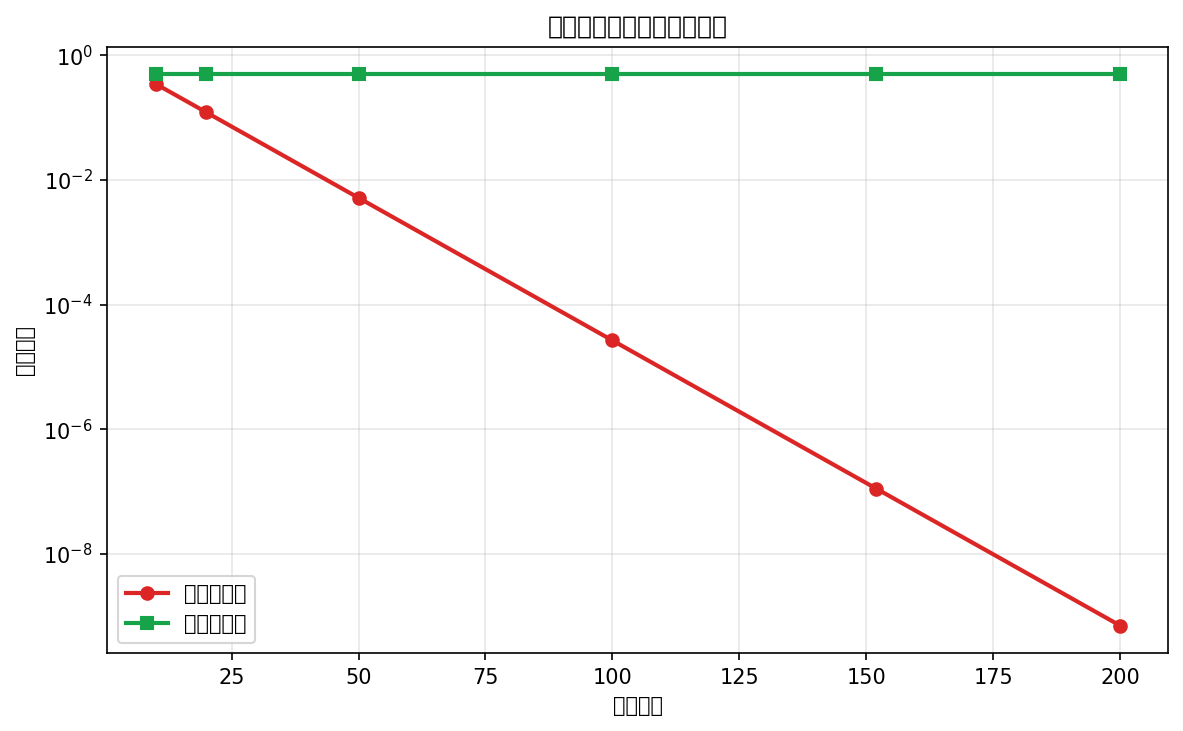

In [5]:
# 从零实现残差块
def residual_block_forward(x, W1, b1, W2, b2, gamma=None, beta=None):
    """残差块前向传播
    x -> Linear -> ReLU -> Linear -> BN -> + x -> ReLU -> out
    """
    identity = x
    z1 = x @ W1 + b1
    a1 = np.maximum(0, z1)
    z2 = a1 @ W2 + b2
    if gamma is not None:
        z2, _ = batchnorm_forward(z2, gamma, beta)
    out = np.maximum(0, z2 + identity)
    return out

# 可视化残差连接的效果
# 模拟梯度流
depths = [10, 20, 50, 100, 152, 200]
without_res = []
with_res = []
for d in depths:
    # 无残差：梯度 ~ (0.9)^d（近似）
    without_res.append(0.9 ** d)
    # 有残差：梯度 ~ max(0.9^d, 1.0)（至少有直连路径）
    with_res.append(max(0.9 ** d, 0.5))

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(depths, without_res, 'o-', label='无残差连接', color='#dc2626', linewidth=2)
ax.semilogy(depths, with_res, 's-', label='有残差连接', color='#16a34a', linewidth=2)
ax.set_xlabel('网络深度')
ax.set_ylabel('梯度强度')
ax.set_title('残差连接对梯度传播的影响')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lecture-06-architectures/residual_gradient.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 架构对比可视化

### 各架构参数量与深度

| 架构 | 深度 | 参数量 | 特点 |
|------|------|--------|------|
| AlexNet | 8 | 60M | 大卷积核, 两GPU |
| VGG-16 | 16 | 138M | 3×3卷积堆叠 |
| GoogLeNet | 22 | 6M | Inception, 1×1卷积 |
| ResNet-50 | 50 | 25M | 瓶颈块, BN |
| ResNet-152 | 152 | 60M | 极深残差 |

VGG 用大量 3×3 卷积堆叠替代大卷积核——两个 3×3 的感受野等于一个 5×5，但参数更少且非线性更强。

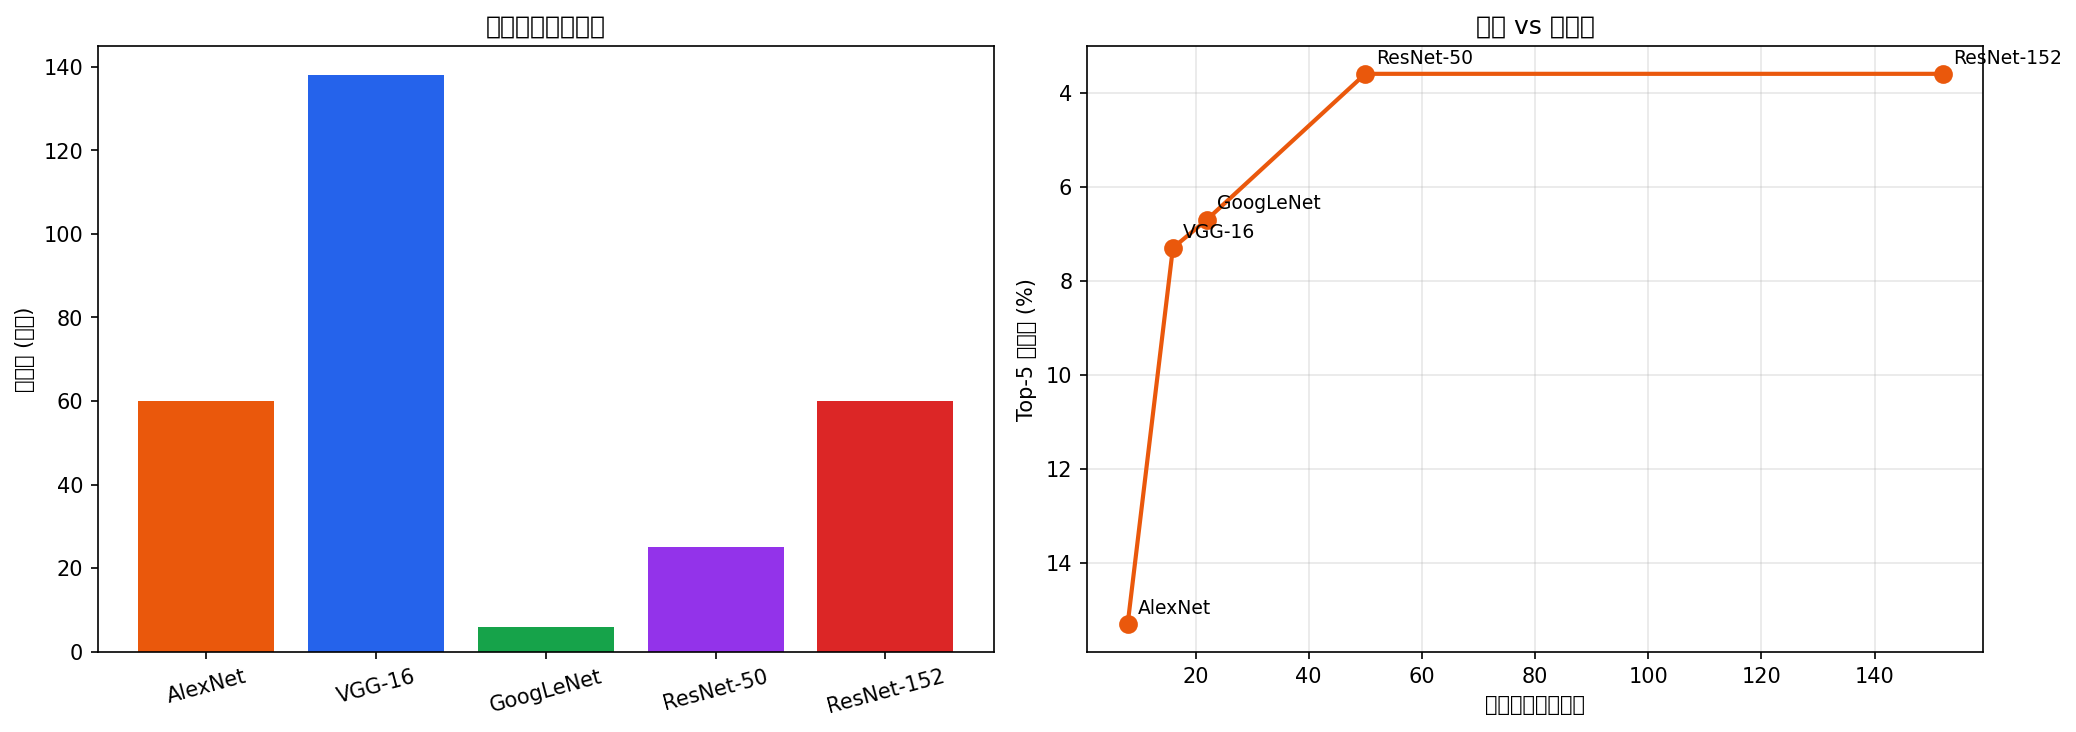

In [7]:
# 可视化架构参数量和深度
architectures = ['AlexNet', 'VGG-16', 'GoogLeNet', 'ResNet-50', 'ResNet-152']
params = [60, 138, 6, 25, 60]  # 百万
depths = [8, 16, 22, 50, 152]
errors = [15.3, 7.3, 6.7, 3.6, 3.6]  # top-5 错误率

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#ea580c', '#2563eb', '#16a34a', '#9333ea', '#dc2626']
ax1.bar(architectures, params, color=colors)
ax1.set_ylabel('参数量 (百万)')
ax1.set_title('各架构参数量对比')
ax1.tick_params(axis='x', rotation=15)

ax2.plot(depths, errors, 'o-', color='#ea580c', linewidth=2, markersize=8)
for d, e, a in zip(depths, errors, architectures):
    ax2.annotate(a, (d, e), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax2.set_xlabel('网络深度（层数）')
ax2.set_ylabel('Top-5 错误率 (%)')
ax2.set_title('深度 vs 准确率')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lecture-06-architectures/architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 作业

### 作业 1：实现瓶颈残差块

ResNet-50 使用瓶颈块（Bottleneck）：1×1 → 3×3 → 1×1，减少计算量。

In [9]:
# 作业 1：计算瓶颈块参数量
# 瓶颈块: 1x1(64) -> 3x3(64) -> 1x1(256)
# 标准块: 3x3(64) -> 3x3(64)

def count_params(kernel_h, kernel_w, in_ch, out_ch):
    return kernel_h * kernel_w * in_ch * out_ch + out_ch

bottleneck = count_params(1,1,256,64) + count_params(3,3,64,64) + count_params(1,1,64,256)
standard = count_params(3,3,256,64) + count_params(3,3,64,64)

print(f"瓶颈块参数量: {bottleneck:,}")
print(f"标准块参数量: {standard:,}")
assert bottleneck < standard, "瓶颈块参数量应更少"
print(f"参数减少: {(1 - bottleneck/standard)*100:.1f}%")
print("作业 1 通过!")

瓶颈块参数量: 70,016
标准块参数量: 184,448
参数减少: 62.0%
作业 1 通过!


## 参考文献

1. **ImageNet Classification with Deep CNNs** - Krizhevsky et al., 2012. [NIPS 2012](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf)
2. **Very Deep Convolutional Networks (VGG)** - Simonyan & Zisserman, 2014. [arXiv:1409.1556](https://arxiv.org/abs/1409.1556)
3. **Going Deeper with Convolutions (GoogLeNet)** - Szegedy et al., 2014. [arXiv:1409.4842](https://arxiv.org/abs/1409.4842)
4. **Deep Residual Learning (ResNet)** - He et al., 2015. [arXiv:1512.03385](https://arxiv.org/abs/1512.03385)
5. **Batch Normalization** - Ioffe & Szegedy, 2015. [arXiv:1502.03167](https://arxiv.org/abs/1502.03167)

---

> 本节内容参考 [Stanford CS231n Lecture 6](https://cs231n.stanford.edu/)